# Lower Confidence Bound

This section demonstrates Bayesian optimization (BO) with lower confidence bound as the acquisition function. This is one of the three strategies presented in this book that combines exploitation and exploration. Specifically, the auxiliary optimization problem is written as:

$$
    \min_{\mathbf{x} \in \Omega} \text{ LCB}(\mathbf{x}),
$$

where LCB is the lower confidence bound and is written as

$$
    \text{LCB}(\mathbf{x}) = \mu(\mathbf{x}) - A \sigma(\mathbf{x}),
$$

where $\mu(\mathbf{x})$ and $\sigma(\mathbf{x})$ are the model prediction and uncertainty in prediction (standard deviation) from surrogate model, and $A$ is a constant that controls the trade-off between exploration and exploitation. Larger the value of $A$, the optimizer will explore search space more. Smaller the value of $A$, optimizer will exploit the current best solution more. The value of $A$ is usually set to 2 or 3.

Below code imports required packages and defines modified branin function:

In [1]:
import numpy as np
import torch
import matplotlib.pyplot as plt
from pyDOE3 import lhs
from scimlstudio.models import SingleOutputGP
from scimlstudio.utils import Standardize, Normalize
from gpytorch.mlls import ExactMarginalLogLikelihood

from pymoo.core.problem import Problem
from pymoo.algorithms.soo.nonconvex.de import DE
from pymoo.optimize import minimize
from pymoo.config import Config
Config.warnings['not_compiled'] = False

# Defining the device and data types
args = {
    "device": torch.device('cuda' if torch.cuda.is_available() else 'cpu'),
    "dtype": torch.float64
}

def modified_branin(x: np.ndarray) -> np.ndarray:
    """
        Function for computing modified branin function value at given input points
    """

    x = np.atleast_2d(x)

    x1 = x[:,0]
    x2 = x[:,1]

    a = 1.
    b = 5.1 / (4.*np.pi**2)
    c = 5. / np.pi
    r = 6.
    s = 10.
    t = 1. / (8.*np.pi)

    y = a * (x2 - b*x1**2 + c*x1 - r)**2 + s*(1-t)*np.cos(x1) + s + 5*x1

    return np.expand_dims(y,-1)

lb = np.array([-5., 0.])
ub = np.array([10., 15.])

/home/pkoratik/miniconda3/envs/sm/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Below code block defines `pymoo` problem class and initializes differential evolution algorithm:

In [2]:
class LowerConfidenceBound(Problem):

    def __init__(self, gp, lb: np.ndarray, ub: np.ndarray, A: int = 2):
        """
            Class for defining auxiliary optimization problem that uses
            lower confidence bound as the acquisition function
        """

        # initialize parent class
        super().__init__(n_var=lb.shape[0], n_obj=1, n_constr=0, xl=lb, xu=ub)

        self.gp = gp # store the surrogate model
        self.A = A

    def _evaluate(self, x, out, *args, **kwargs):

        # convert to torch tensor
        x = torch.from_numpy(x).to(self.gp.x_train)

        # get mean prediction and std in prediction
        y_mean, y_std = self.gp.predict(x)

        # store the objective value as numpy array
        out["F"] = y_mean.numpy(force=True) + self.A * y_std.numpy(force=True)

# Optimization algorithm
algorithm = DE(pop_size=15*lb.shape[0], F=0.9, CR=0.8, seed=1)

## BO loop

Below code implements BO loop with lcb-based acquisition function. Four initial samples are used with a maximum function evaluation budget of 12. This implies that there will be 8 iterations of the loop. The initial samples are generated using latin hypercube sampling. A Gaussian process model is used to approximate the modified Branin function since it provides both point-prediction and uncertainty in prediction.

In [3]:
# variables
A = 3
num_init = 4
max_evals = 24
num_evals = 0

# initial training data
x_train = lhs(lb.shape[0], samples=num_init, criterion='cm', iterations=100, seed=1)
x_train = lb + (ub - lb) * x_train
y_train = modified_branin(x_train)

# increment evals
num_evals += num_init

idx_best = np.argmin(y_train)
fbest = [y_train[idx_best]]
xbest = [x_train[idx_best]]

print("Current best before loop:")
print("x: {}".format(xbest[-1]))
print("f: {}".format(fbest[-1]))

print("\nLCB Loop:")

# loop
while num_evals < max_evals:

    print(f"\nIteration: {num_evals-num_init+1}")

    # GP
    gp = SingleOutputGP(
        x_train=torch.from_numpy(x_train).to(**args),
        y_train=torch.from_numpy(y_train).to(**args),
        output_transform=Standardize,
        input_transform=Normalize,
    )

    mll = ExactMarginalLogLikelihood(gp.likelihood, gp) # marginal log likelihood

    optimizer = torch.optim.Adam(gp.parameters(), lr=0.01) # optimizer

    # Training the model
    gp.fit(training_iterations=1000, mll=mll, optimizer=optimizer)

    # Find the minimum of surrogate model
    result = minimize(LowerConfidenceBound(gp, lb, ub, A), algorithm, verbose=False)

    # Computing true function value at infill point
    y_infill = modified_branin(result.X)

    print("New point (based on LCB):")
    print("x: {}".format(result.X))
    print("f: {}".format(y_infill.item()))

    # Appending the the new point to the current data set
    x_train = np.vstack(( x_train, result.X.reshape(1,-1) ))
    y_train = np.vstack((y_train, y_infill))

    # increment evals
    num_evals += 1

    # Find current best point
    idx_best = np.argmin(y_train)
    fbest.append(y_train[idx_best])
    xbest.append(x_train[idx_best])
    
    print("Current best:")
    print("x: {}".format(xbest[-1]))
    print("f: {}".format(fbest[-1]))

fbest = np.array(fbest)
xbest = np.array(xbest)

Current best before loop:
x: [-3.125  5.625]
f: [28.46841701]

LCB Loop:

Iteration: 1


/home/pkoratik/miniconda3/envs/sm/lib/python3.12/site-packages/gpytorch/distributions/multivariate_normal.py:376: NumericalWarning: Negative variance values detected. This is likely due to numerical instabilities. Rounding negative variances up to 1e-10.
  warnings.warn(


New point (based on LCB):
x: [-3.12499838  5.62495876]
f: 28.468919084357086
Current best:
x: [-3.125  5.625]
f: [28.46841701]

Iteration: 2
New point (based on LCB):
x: [-3.14116757  6.0575758 ]
f: 23.335712244992262
Current best:
x: [-3.14116757  6.0575758 ]
f: [23.33571224]

Iteration: 3
New point (based on LCB):
x: [-3.16788234  6.78588662]
f: 15.390751465564394
Current best:
x: [-3.16788234  6.78588662]
f: [15.39075147]

Iteration: 4
New point (based on LCB):
x: [-3.23402029  8.62969069]
f: -0.765636957681977
Current best:
x: [-3.23402029  8.62969069]
f: [-0.76563696]

Iteration: 5
New point (based on LCB):
x: [-3.34101727 11.57146708]
f: -14.705700727058767
Current best:
x: [-3.34101727 11.57146708]
f: [-14.70570073]

Iteration: 6
New point (based on LCB):
x: [-3.38887011 12.81080968]
f: -16.249986769560593
Current best:
x: [-3.38887011 12.81080968]
f: [-16.24998677]

Iteration: 7
New point (based on LCB):
x: [-3.39363133 12.93040373]
f: -16.26517917282152
Current best:
x: [-3.39

Below code plots the evolution of optimum point with respect to number of iterations:

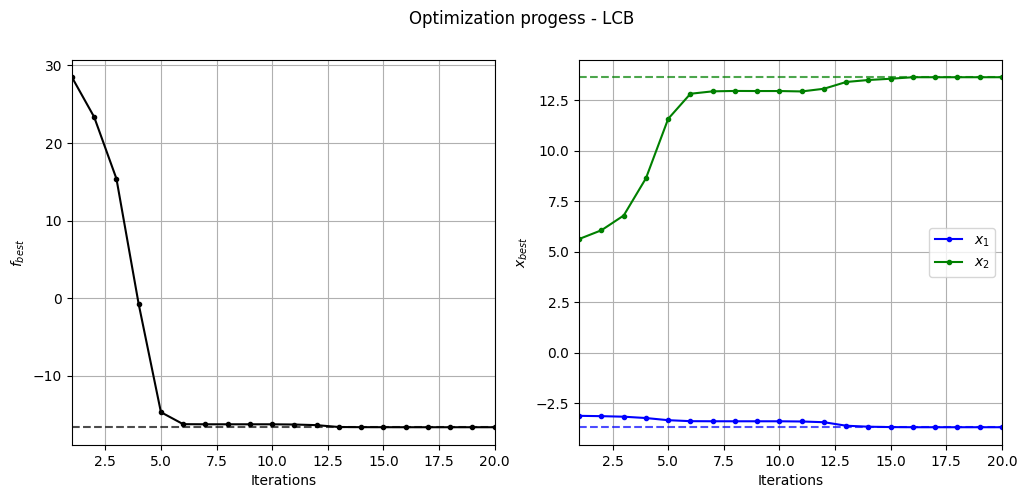

In [4]:
fig, ax = plt.subplots(1, 2, figsize=(12, 5))

ax[0].plot(fbest, ".k-")
ax[0].set_xlabel("Iterations")
ax[0].set_ylabel("$f_{best}$")
ax[0].axhline(y=-16.64, c="k", linestyle="--", alpha=0.7)
ax[0].set_xlim(left=1, right=fbest.shape[0]-1)
ax[0].grid()

ax[1].plot(xbest[:,0], ".b-", label="$x_1$")
ax[1].plot(xbest[:,1], ".g-", label="$x_2$")
ax[1].axhline(y=-3.689, c="b", linestyle="--", alpha=0.7)
ax[1].axhline(y=13.630, c="g", linestyle="--", alpha=0.7)
ax[1].set_xlim(left=1, right=xbest.shape[0]-1)
ax[1].set_ylabel("$x_{best}$")
ax[1].set_xlabel("Iterations")
ax[1].legend()
ax[1].grid()

_ = plt.suptitle("Optimization progess - LCB")

Below code plots the infill points added during the optimization process:

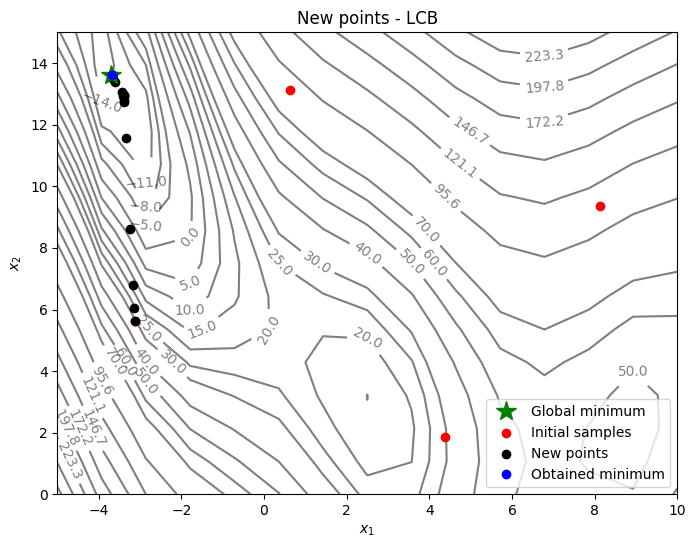

In [5]:
num_pts_per_dim = 15
x1 = np.linspace(lb[0], ub[0], num_pts_per_dim)
x2 = np.linspace(lb[1], ub[1], num_pts_per_dim)
X1, X2 = np.meshgrid(x1, x2)

x = np.hstack(( X1.reshape(-1,1), X2.reshape(-1,1) ))

Z = modified_branin(x).reshape(num_pts_per_dim, num_pts_per_dim)

# Level
levels = np.linspace(-17, -5, 5)
levels = np.concatenate((levels, np.linspace(0, 30, 7)))
levels = np.concatenate((levels, np.linspace(40, 60, 3)))
levels = np.concatenate((levels, np.linspace(70, 300, 10)))

fig, ax = plt.subplots(figsize=(8,6))

# Contours and global opt
CS=ax.contour(X1, X2, Z, levels=levels, colors='k', linestyles='solid', alpha=0.5, zorder=-10)
ax.clabel(CS, inline=1)
ax.plot(-3.689, 13.630, 'g*', markersize=15, label="Global minimum")

# Points
ax.scatter(x_train[0:num_init,0], x_train[0:num_init,1], c="red", label='Initial samples')
ax.scatter(x_train[num_init:,0], x_train[num_init:,1], c="black", label='New points')
ax.plot(xbest[-1][0], xbest[-1][1], 'bo', label="Obtained minimum")

# asthetics
ax.legend()
ax.set_xlabel("$x_1$")
ax.set_ylabel("$x_2$")
_ = ax.set_title("New points - LCB")

As can be seen in above plots, the convergence is much faster than pure exploitation-based acquisition function. But it is hard to know what value of $A$ to use. You can change the value of $A$ and see how it changes the optimization convergence.

> __*NOTE*__: Due to randomness in GP training and differential evolution, results may vary slightly between runs. So, it is recommend to run the code multiple times to see average behavior.